# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Stella!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [35]:
from plot_bowtie import plot_bowtie_blocks, plot_bowtie_fluxes

## Load data

In [13]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
BIPARTITE_FOLDER=HOME+'guarino_files/'

# Looking into the abyss

In [14]:
guarino_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

### Name of the various dicos

In [15]:
with open(BIPARTITE_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()

In [16]:
cacca

['quirinale\n',
 '5: journalists & Media\n',
 '2: M5S\n',
 '0: journalists & IV & Azione & +Europa & Media\n',
 '4: Lega & FDI\n',
 '1: PD\n',
 '3: Media & journalists\n',
 '6: FI\n',
 '\n',
 'crisi\n',
 '1: Lega & FDI & FI\n',
 '2: M5S & journalists\n',
 '0: journalists & IV & Media & Azione & +Europa\n',
 '4: Media & journalists\n',
 '3: PD\n',
 '\n',
 'ita_elections\n',
 '1: PD & Media & +Europa & journalists\n',
 '2: M5S & Media\n',
 '3: journalists & IV & Azione\n',
 '0: Lega & FDI & FI\n',
 '4: journalists & Media (1)\n',
 '5: Media\n',
 '6: journalists & Media (2)\n',
 '\n']

In [17]:
with open(BIPARTITE_FOLDER+guarino_files[6], 'rb') as f:
    cacca = pickle.load(f)

In [18]:
cacca

{np.int64(1): 'Lega & FDI & FI',
 np.int64(2): 'M5S & journalists',
 np.int64(0): 'journalists & IV & Media & Azione & +Europa',
 np.int64(4): 'Media & journalists',
 np.int64(3): 'PD'}

The pickle is what I need.

### From Guarino to my (actually, Sonnet's...) standards

In [25]:
cacca=np.genfromtxt(BIPARTITE_FOLDER+guarino_files[1], delimiter=',', dtype=int, skip_header=1)
header = np.genfromtxt(BIPARTITE_FOLDER+guarino_files[1], delimiter=',', dtype=str, max_rows=1)
header=[str(h) for h in header]

In [56]:
guarino_files[1]

'crisi_dico_0_bowtie_sizes.csv'

In [30]:
header

['IN', 'IN-TENDRILS', 'LSCC', 'OTHERS', 'OUT', 'OUT-TENDRILS', 'TUBES']

In [34]:
with open(PVALUE_FOLDER+'crisi_dico0_pvalues_blocks_0.pkl', 'rb') as f:
    block_dict_0 = pickle.load(f)
with open(PVALUE_FOLDER+'crisi_dico0_pvalues_fluxes_0.pkl', 'rb') as f:
    flux_dict_0 = pickle.load(f)

In [21]:
block_dict_0

defaultdict(dict,
            {'OUT': {'obs': 33640,
              'mean_sim': 34817.4252,
              'std_sim': np.float64(306.5698152219566),
              'tail': 'left',
              'p_value': 0.0008},
             'INTENDRILS': {'obs': 14687,
              'mean_sim': 4390.776,
              'std_sim': np.float64(290.7526031250675),
              'tail': 'right',
              'p_value': 0.0},
             'SCC': {'obs': 3513,
              'mean_sim': 3376.621,
              'std_sim': np.float64(45.93500363557738),
              'tail': 'right',
              'p_value': 0.0032},
             'OUTTENDRILS': {'obs': 2150,
              'mean_sim': 1261.5888,
              'std_sim': np.float64(38.8600323540792),
              'tail': 'right',
              'p_value': 0.0},
             'OTHERS': {'obs': 2237,
              'mean_sim': 160.8636,
              'std_sim': np.float64(15.596069858781837),
              'tail': 'right',
              'p_value': 0.0},
             '

In [45]:
block_dict_bipartite={}

for i, name in enumerate(header):
    if name=='LSCC':
        key='SCC'
    else:
        key=name.replace('-','')
    block_dict_bipartite[key] = {}
    block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
    block_dict_bipartite[key]['sample']=cacca[:,i]
    _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
    _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
    block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
    _median=np.median(block_dict_bipartite[key]['sample'])
    if _median>block_dict_bipartite[key]['obs']:
        block_dict_bipartite[key]['tail']='right'
    else:
        block_dict_bipartite[key]['tail']='left'
    

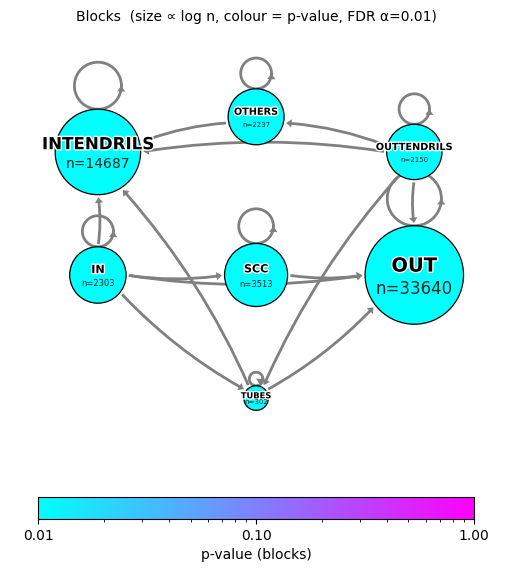

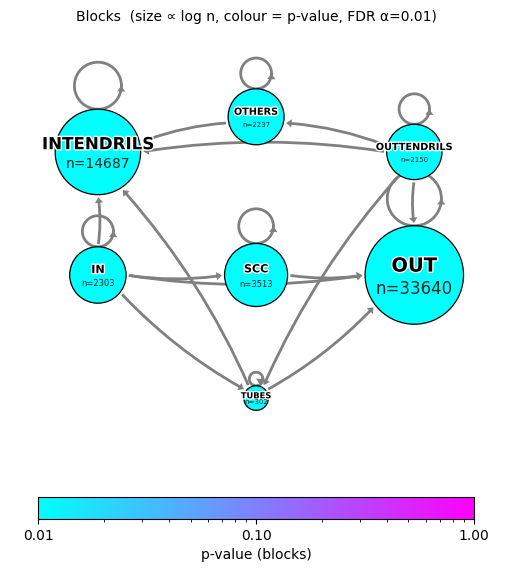

In [46]:
plot_bowtie_blocks(block_dict_bipartite, flux_dict_0, ALPHA)

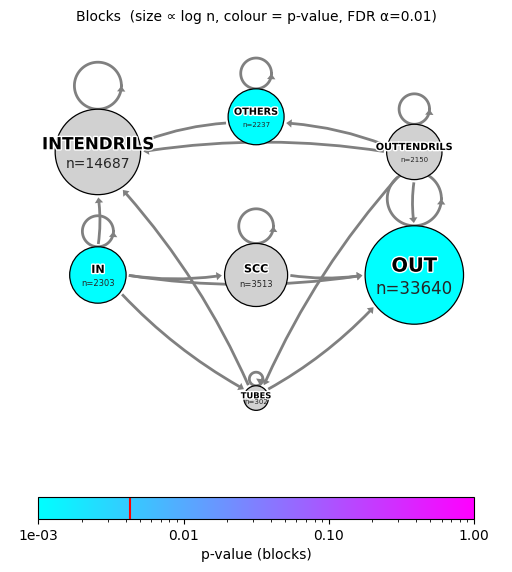

In [47]:
right_tailed_blocks={}
for key, item in block_dict_bipartite.items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, flux_dict_0, 0.01)
plt.show()

# Replicating the benchmark in the draft submitted to NetSci

## Functions

In [59]:
# by default, it uses pvalues_blocks_0.pkl 
def guarino2dict_blocks(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    # load the "monopartite" dict
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_0.pkl', 'rb') as f:
        block_dict_0 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_0.pkl', 'rb') as f:
        flux_dict_0 = pickle.load(f)

    block_dict_bipartite={}

    for i, name in enumerate(header):
        if name=='LSCC':
            key='SCC'
        else:
            key=name.replace('-','')
        block_dict_bipartite[key] = {}
        block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
        block_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
        block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
        _median=np.median(block_dict_bipartite[key]['sample'])
        if _median>block_dict_bipartite[key]['obs']:
            block_dict_bipartite[key]['tail']='right'
        else:
            block_dict_bipartite[key]['tail']='left'
    return block_dict_bipartite, block_dict_0, flux_dict_0



In [72]:
def right_tailer(block_dict):
    right_tailed_dict={}
    for key, item in block_dict.items():
        right_tailed_dict[key] = item
        if item['tail'] == 'right':
            right_tailed_dict[key]['p_value'] /=2
        else:
            right_tailed_dict[key]['p_value']=1.
    return right_tailed_dict


## Plots

In [53]:
labels_file=[file for file in guarino_files if file.endswith('.pickle') and file.startswith('ita')][0]

In [54]:
labels=pickle.load(open(BIPARTITE_FOLDER+labels_file, 'rb'))

In [55]:
labels

{np.int64(1): 'PD & Media & +Europa & journalists',
 np.int64(2): 'M5S & Media',
 np.int64(3): 'journalists & IV & Azione',
 np.int64(0): 'Lega & FDI & FI',
 np.int64(4): 'journalists & Media (1)',
 np.int64(5): 'Media',
 np.int64(6): 'journalists & Media (2)'}

In [60]:
blocks=guarino2dict_blocks('ita_elections', 0)

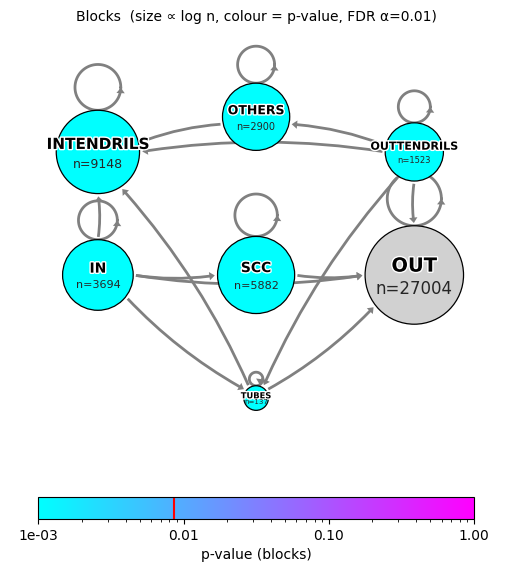

In [67]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

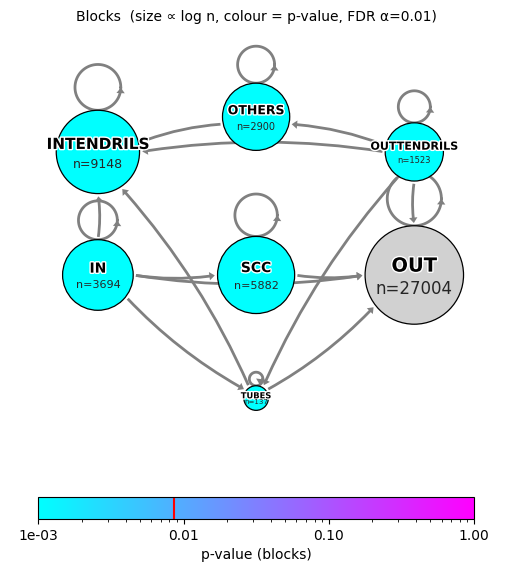

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [75]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=1.00e+00, tail=left
INTENDRILS: p-value=1.00e+00, tail=left
SCC: p-value=1.00e+00, tail=left
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=2.77e-01, tail=right
OUTTENDRILS: p-value=1.00e+00, tail=left
TUBES: p-value=1.00e+00, tail=left


In [76]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=1.00e+00, tail=left
SCC: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


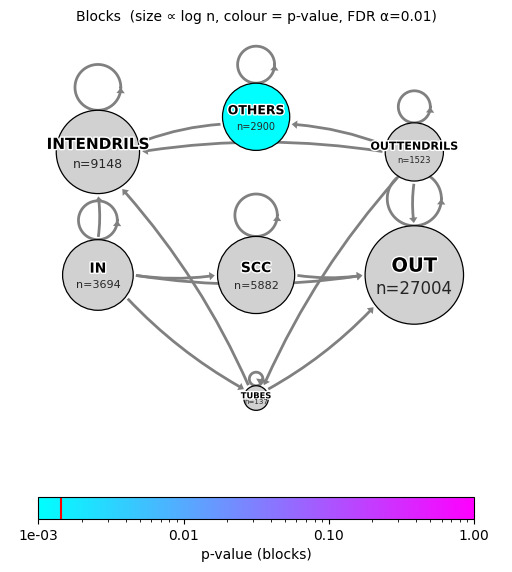

In [73]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

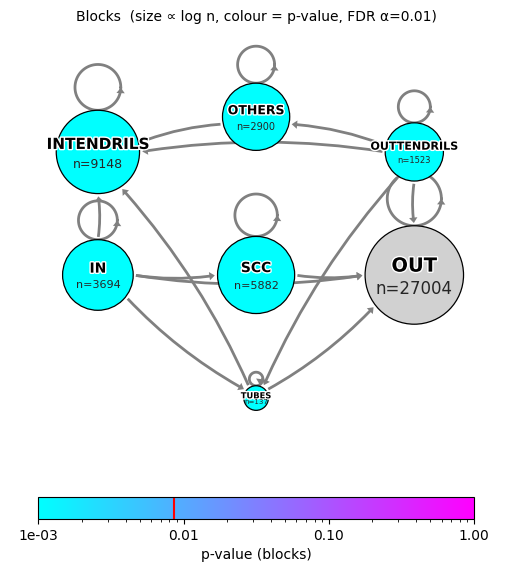

In [74]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()